In [1]:
!pip install -q ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import requests
import zipfile
import io
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

from ydata_profiling import ProfileReport

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


/tmp/ipykernel_1418/1863374384.py:11: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [6]:
# World Bank CSV download URL
csv_url = (
    "https://api.worldbank.org/v2/country/all/"
    "indicator/SP.POP.TOTL"
    "?downloadformat=csv"
)

# Download the ZIP file
response = requests.get(csv_url, timeout=60)
response.raise_for_status()

# Extract CSV files from ZIP
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    csv_files = z.namelist()

    # Correctly identify the population data file
    data_file = next(
        f for f in csv_files
        if f.startswith("API_SP.POP.TOTL") and f.endswith(".csv")
    )

    country_file = next(
        f for f in csv_files
        if "Metadata_Country" in f and f.endswith(".csv")
    )

    population_raw = pd.read_csv(
        z.open(data_file),
        skiprows=4
    )

    country_metadata = pd.read_csv(
        z.open(country_file)
    )

# Select the year for analysis
year = "2022"

# Keep country names and population
csv_df = population_raw[["Country Name", "Country Code", year]].copy()

# Rename columns, ensuring 'Country Code' is consistent for merge
csv_df.columns = ["Country", "Country Code", "Population"]

# Remove regional and income-group aggregates
country_metadata = country_metadata[
    ["Country Code", "Region"]
]

csv_df = csv_df.merge(
    country_metadata,
    on="Country Code",
    how="left"
)

csv_df = csv_df[
    csv_df["Region"].notna()
    & (csv_df["Region"] != "")
]

csv_df = csv_df[
    ["Country", "Country Code", "Population", "Region"]
]

csv_df = csv_df.dropna(subset=["Population"])

csv_df["Population"] = pd.to_numeric(
    csv_df["Population"],
    errors="coerce"
)

csv_df = csv_df.dropna(subset=["Population"])

csv_df = csv_df.reset_index(drop=True)

print("CSV data collected successfully!")
print("Dataset shape:", csv_df.shape)

csv_df.head()

CSV data collected successfully!
Dataset shape: (217, 4)


,Country,Country Code,Population,Region
0,Aruba,ABW,107310.0,Latin America & Caribbean
1,Afghanistan,AFG,40578842.0,Middle East & North Africa
2,Angola,AGO,35635029.0,Sub-Saharan Africa
3,Albania,ALB,2451636.0,Europe & Central Asia
4,Andorra,AND,79705.0,Europe & Central Asia


In [9]:
api_url = (
    "https://api.worldbank.org/v2/country/all/"
    "indicator/SP.POP.TOTL"
)

params = {
    "format": "json",
    "date": year,
    "per_page": 20000
}

api_response = requests.get(
    api_url,
    params=params,
    timeout=60
)

api_response.raise_for_status()

api_json = api_response.json()

# The second item contains the actual records
records = api_json[1]

api_df = pd.DataFrame([
    {
        "Country": row["country"]["value"],
        "Country Code": row["countryiso3code"], # Changed 'Country_Code' to 'Country Code'
        "Population": row["value"],
        "Year": int(row["date"])
    }
    for row in records
    if row["value"] is not None
    and row["countryiso3code"]
])

# Remove regional aggregates using the CSV country metadata
api_df = api_df.merge(
    country_metadata,
    on="Country Code",
    how="left"
)

api_df = api_df[
    api_df["Region"].notna()
    & (api_df["Region"] != "")
]

api_df = api_df.reset_index(drop=True)

print("API data collected successfully!")
print("Dataset shape:", api_df.shape)

api_df.head()

API data collected successfully!
Dataset shape: (217, 5)


,Country,Country Code,Population,Year,Region
0,Afghanistan,AFG,40578842,2022,Middle East & North Africa
1,Albania,ALB,2451636,2022,Europe & Central Asia
2,Algeria,DZA,45477389,2022,Middle East & North Africa
3,American Samoa,ASM,48342,2022,East Asia & Pacific
4,Andorra,AND,79705,2022,Europe & Central Asia


In [11]:
print("CSV method")
print("Rows:", len(csv_df))
print("Columns:", len(csv_df.columns))

print("\nAPI method")
print("Rows:", len(api_df))
print("Columns:", len(api_df.columns))

# Compare country populations
csv_compare = csv_df[
    ["Country Code", "Population"] # Changed 'Country_Code' to 'Country Code'
].rename(
    columns={"Population": "CSV_Population"}
)

api_compare = api_df[
    ["Country Code", "Population"] # Changed 'Country_Code' to 'Country Code'
].rename(
    columns={"Population": "API_Population"}
)

comparison = csv_compare.merge(
    api_compare,
    on="Country Code", # Changed 'Country_Code' to 'Country Code'
    how="inner"
)

comparison["Difference"] = (
    comparison["CSV_Population"]
    - comparison["API_Population"]
)

print("\nNumber of matched countries:", len(comparison))

print(
    "All matched population values equal:",
    np.allclose(
        comparison["CSV_Population"],
        comparison["API_Population"]
    )
)

comparison.head()

CSV method
Rows: 217
Columns: 4

API method
Rows: 217
Columns: 5

Number of matched countries: 217
All matched population values equal: True


,Country Code,CSV_Population,API_Population,Difference
0,ABW,107310.0,107310,0.0
1,AFG,40578842.0,40578842,0.0
2,AGO,35635029.0,35635029,0.0
3,ALB,2451636.0,2451636,0.0
4,AND,79705.0,79705,0.0


In [12]:
df = csv_df.copy()

df.to_csv(
    "world_population_2022.csv",
    index=False
)

print("Dataset saved successfully!")

df.head()

Dataset saved successfully!


,Country,Country Code,Population,Region
0,Aruba,ABW,107310.0,Latin America & Caribbean
1,Afghanistan,AFG,40578842.0,Middle East & North Africa
2,Angola,AGO,35635029.0,Sub-Saharan Africa
3,Albania,ALB,2451636.0,Europe & Central Asia
4,Andorra,AND,79705.0,Europe & Central Asia


In [13]:
# Basic overview
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
display(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

First 5 rows:


,Country,Country Code,Population,Region
0,Aruba,ABW,107310.0,Latin America & Caribbean
1,Afghanistan,AFG,40578842.0,Middle East & North Africa
2,Angola,AGO,35635029.0,Sub-Saharan Africa
3,Albania,ALB,2451636.0,Europe & Central Asia
4,Andorra,AND,79705.0,Europe & Central Asia



Last 5 rows:


,Country,Country Code,Population,Region
212,Kosovo,XKX,1768096.0,Europe & Central Asia
213,"Yemen, Rep.",YEM,38222876.0,Middle East & North Africa
214,South Africa,ZAF,62378410.0,Sub-Saharan Africa
215,Zambia,ZMB,20152938.0,Sub-Saharan Africa
216,Zimbabwe,ZWE,16069056.0,Sub-Saharan Africa



Dataset shape:
(217, 4)

Column names:
['Country', 'Country Code', 'Population', 'Region']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       217 non-null    object 
 1   Country Code  217 non-null    object 
 2   Population    217 non-null    float64
 3   Region        217 non-null    object 
dtypes: float64(1), object(3)
memory usage: 6.9+ KB

Statistical summary:


,Population
count,2.170000e+02
mean,3.670675e+07
std,1.415287e+08
min,9.992000e+03
25%,8.216370e+05
50%,6.664449e+06
75%,2.601872e+07
max,1.425423e+09



Missing values:
Country         0
Country Code    0
Population      0
Region          0
dtype: int64

Duplicate rows:
0

Data types:
Country          object
Country Code     object
Population      float64
Region           object
dtype: object


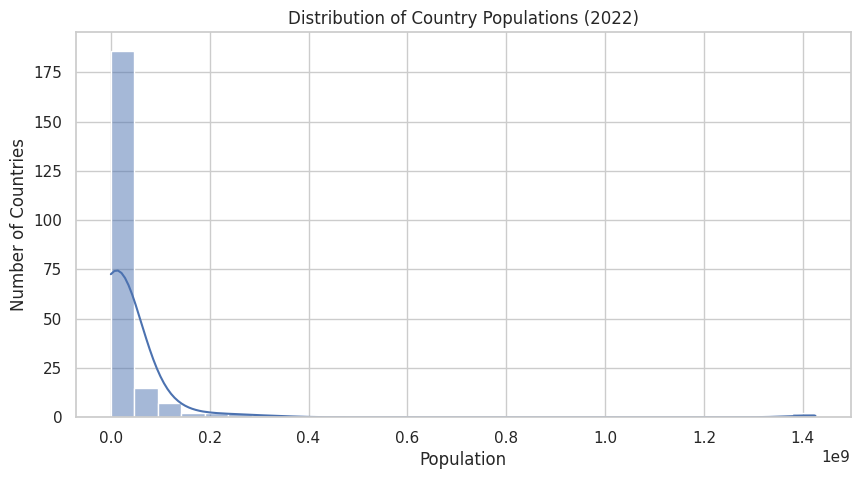

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Population",
    bins=30,
    kde=True
)

plt.title("Distribution of Country Populations (2022)")
plt.xlabel("Population")
plt.ylabel("Number of Countries")
plt.show()

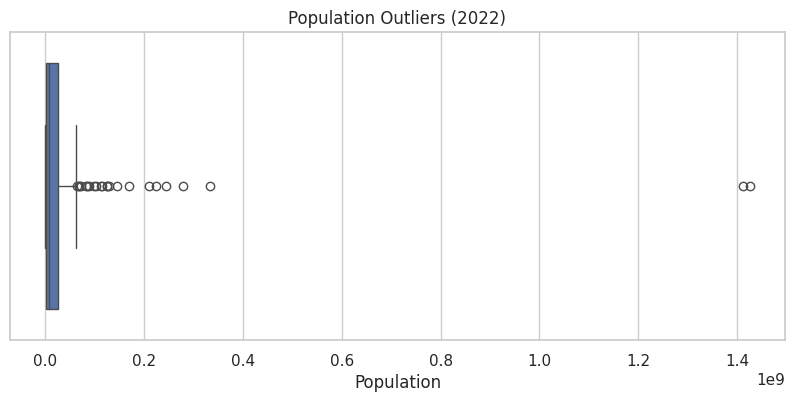

In [17]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="Population"
)

plt.title("Population Outliers (2022)")
plt.xlabel("Population")
plt.show()

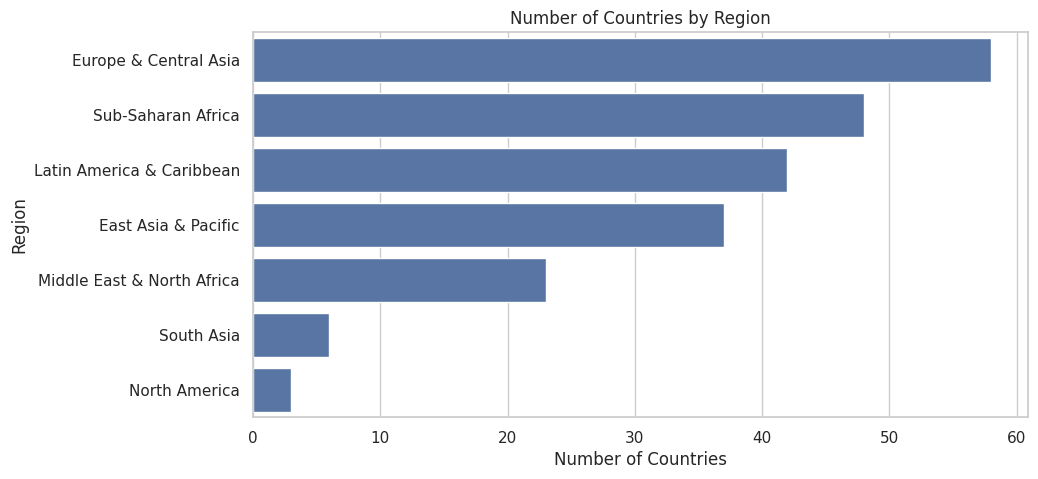

In [19]:
countries = df.drop_duplicates(subset="Country Code")

plt.figure(figsize=(10, 5))

sns.countplot(
    data=countries,
    y="Region",
    order=countries["Region"].value_counts().index
)

plt.title("Number of Countries by Region")
plt.xlabel("Number of Countries")
plt.ylabel("Region")
plt.show()

In [21]:
population_2022 = df['Population']

print("Mean:", population_2022.mean())
print("Median:", population_2022.median())
print("Minimum:", population_2022.min())
print("Maximum:", population_2022.max())
print("Standard deviation:", population_2022.std())

Mean: 36706746.18894009
Median: 6664449.0
Minimum: 9992.0
Maximum: 1425423212.0
Standard deviation: 141528692.84068066


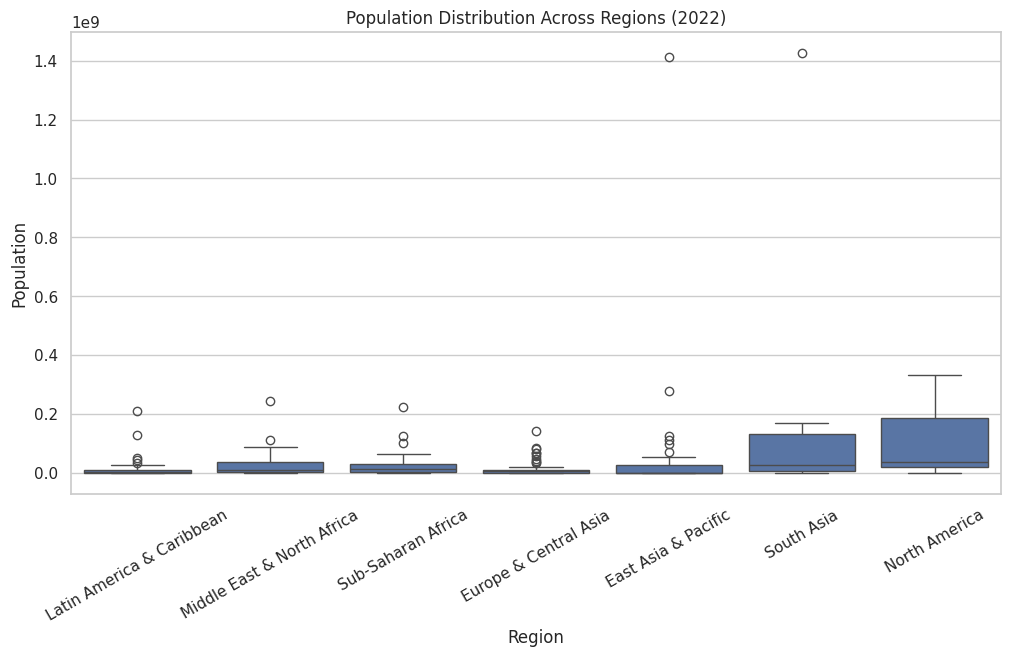

In [23]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Region",
    y="Population"
)

plt.title("Population Distribution Across Regions (2022)")
plt.xlabel("Region")
plt.ylabel("Population")
plt.xticks(rotation=30)
plt.show()

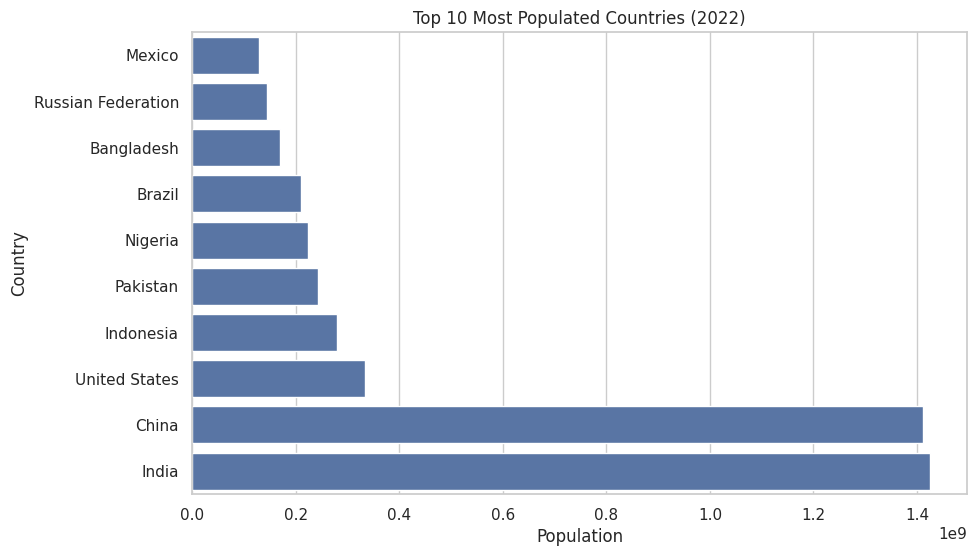

,Country,Region,Population
125,Mexico,Latin America & Caribbean,1.286131e+08
165,Russian Federation,Europe & Central Asia,1.442369e+08
17,Bangladesh,South Asia,1.693849e+08
26,Brazil,Latin America & Caribbean,2.103064e+08
142,Nigeria,Sub-Saharan Africa,2.231509e+08
150,Pakistan,Middle East & North Africa,2.437007e+08
87,Indonesia,East Asia & Pacific,2.788305e+08
203,United States,North America,3.339963e+08
36,China,East Asia & Pacific,1.412175e+09
89,India,South Asia,1.425423e+09


In [25]:
top_10 = (
    df
    .nlargest(10, "Population")
    .sort_values("Population")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10,
    x="Population",
    y="Country"
)

plt.title("Top 10 Most Populated Countries (2022)")
plt.xlabel("Population")
plt.ylabel("Country")
plt.show()

display(
    top_10[["Country", "Region", "Population"]]
)

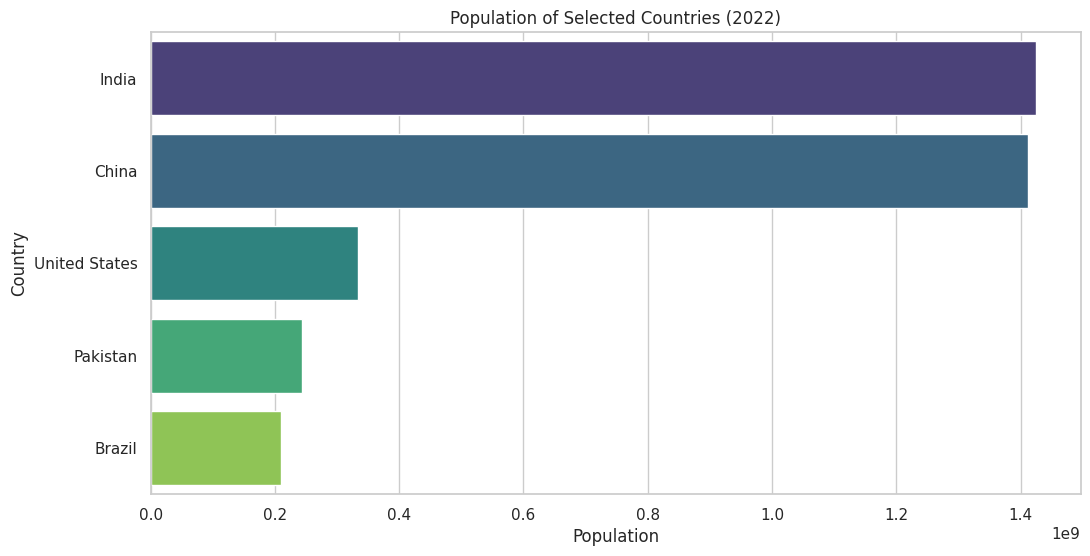

In [28]:
selected_countries = [
    "Pakistan",
    "India",
    "China",
    "United States",
    "Brazil"
]

trend_df = df[
    df["Country"].isin(selected_countries)
]

plt.figure(figsize=(12, 6))

sns.barplot(
    data=trend_df.sort_values("Population", ascending=False),
    x="Population",
    y="Country",
    hue="Country",
    palette="viridis"
)

plt.title("Population of Selected Countries (2022)")
plt.xlabel("Population")
plt.ylabel("Country")
# plt.xticks(years) # Removed as 'years' is undefined and not applicable with current data
# plt.legend(title="Country") # Removed as seaborn with 'hue' automatically handles the legend
plt.show()

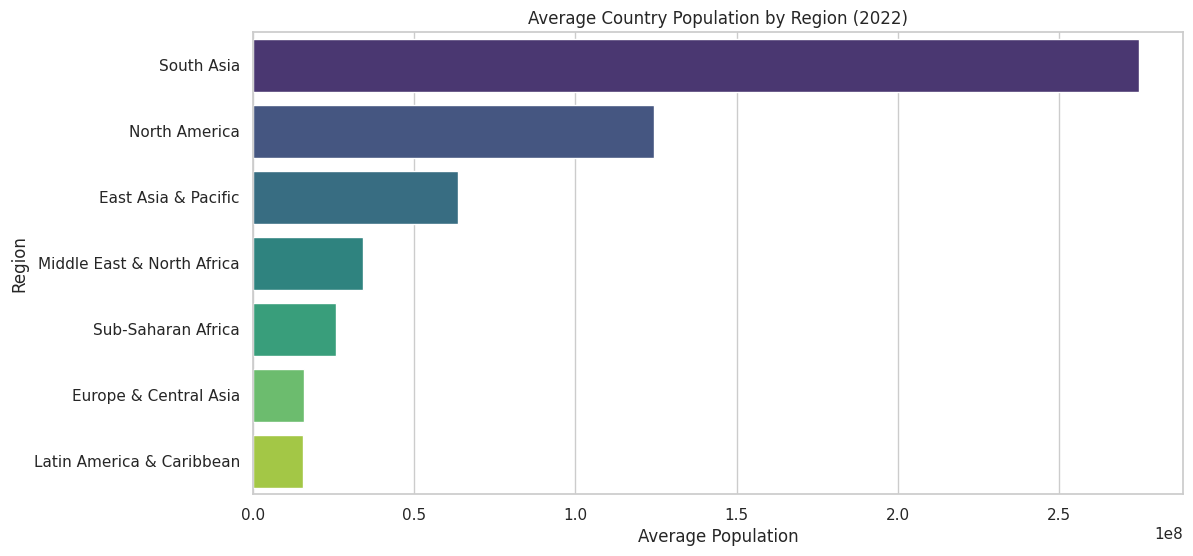

In [31]:
regional_population = (
    df.groupby("Region")["Population"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=regional_population.sort_values("Population", ascending=False),
    x="Population",
    y="Region",
    hue="Region", # Assign 'Region' to hue as suggested by the warning
    palette="viridis",
    legend=False # Set legend to False to avoid redundancy
)

plt.title("Average Country Population by Region (2022)")
plt.xlabel("Average Population")
plt.ylabel("Region")
# plt.legend(title="Region", bbox_to_anchor=(1.05, 1)) # Removed as it's not applicable for this barplot without a 'hue'
plt.show()

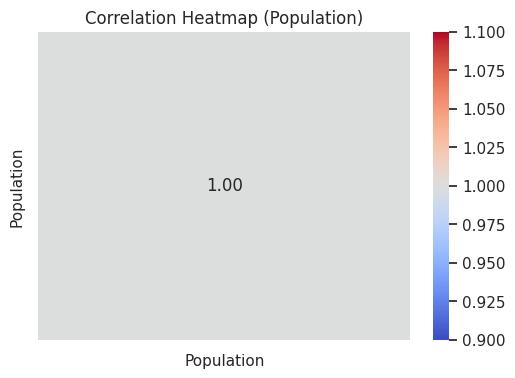

In [33]:
correlation_data = df[
    ["Population"] # 'Year' column does not exist in df, as it contains only 2022 data.
].corr()

plt.figure(figsize=(6, 4))

sns.heatmap(
    correlation_data,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap (Population)") # Updated title to reflect content
plt.show()

In [34]:
profile = ProfileReport(
    df,
    title="World Population Dataset - EDA Report",
    explorative=True
)

profile.to_file("population_eda_report.html")

print("EDA report generated successfully!")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 4/4 [00:00<00:00, 42.38it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

EDA report generated successfully!


In [35]:
from IPython.display import IFrame, display

display(
    IFrame(
        src="population_eda_report.html",
        width="100%",
        height=600
    )
)

In [37]:
latest_year = 2022

latest_data = df.copy()

# Finding 1: Most populated country
largest_country = latest_data.loc[
    latest_data["Population"].idxmax()
]

# Finding 2: Least populated country in the dataset
smallest_country = latest_data.loc[
    latest_data["Population"].idxmin()
]

# Finding 3: Region with the highest average country population
region_average = (
    latest_data.groupby("Region")["Population"]
    .mean()
    .sort_values(ascending=False)
)

largest_region = region_average.index[0]

print("FINDINGS")
print("-" * 50)

print(
    f"1. In {latest_year}, {largest_country['Country']} "
    f"had the largest population in the dataset, "
    f"with approximately {largest_country['Population']:,.0f} people."
)

print(
    f"2. In {latest_year}, {smallest_country['Country']} "
    f"had the smallest population among the countries "
    f"included in the dataset, with approximately "
    f"{smallest_country['Population']:,.0f} people."
)

print(
    f"3. {largest_region} had the highest average "
    f"country population in {latest_year}, at approximately "
    f"{region_average.iloc[0]:,.0f} people per country."
)

FINDINGS
--------------------------------------------------
1. In 2022, India had the largest population in the dataset, with approximately 1,425,423,212 people.
2. In 2022, Tuvalu had the smallest population among the countries included in the dataset, with approximately 9,992 people.
3. South Asia had the highest average country population in 2022, at approximately 274,668,261 people per country.


In [38]:
from google.colab import files

# Save the final cleaned dataset
df.to_csv(
    "cleaned_population_dataset.csv",
    index=False
)

# Save the API dataset
api_df.to_csv(
    "world_population_api_2022.csv",
    index=False
)

# Save the comparison
comparison.to_csv(
    "csv_vs_api_comparison.csv",
    index=False
)

# Download the files
files.download("cleaned_population_dataset.csv")
files.download("world_population_api_2022.csv")
files.download("csv_vs_api_comparison.csv")
files.download("population_eda_report.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>